# **AMAZON SALES DATA ANALYSIS** #

### NAME: EMMANUEL BERYL
### COURSE: INTRODUCTION TO DATA ANALYSIS WITH PYTHON
### DATE: MAY 2026


### This Dataset contains Amazon sales transactions including product category, sales amout, quantity, customer details, and order date

### the aim of this analysis is to identify sales trends, top_performing categories, customer purchasing patterns, and business insights.

In [1]:
import pandas as pd

In [12]:
import numpy as np

In [13]:
import seaborn as sb

In [4]:
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv(r'C:\Users\HP\Documents\Amazon Sale Report.csv')

In [7]:
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by
0,0,405-8078784-5731545,4/30/2022,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship
1,1,171-9198151-1101146,4/30/2022,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship
2,2,404-0687676-7273146,4/30/2022,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN
3,3,403-9615377-8133951,4/30/2022,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship
4,4,407-1069790-7240320,4/30/2022,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN


In [9]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by'],
      dtype='object')

In [10]:
df.describe()

,index,Qty,Amount,ship-postal-code
count,128975.000000,128975.000000,121180.000000,128942.000000
mean,64487.000000,0.904431,648.561465,463966.236509
std,37232.019822,0.313354,281.211687,191476.764941
min,0.000000,0.000000,0.000000,110001.000000
25%,32243.500000,1.000000,449.000000,382421.000000
50%,64487.000000,1.000000,605.000000,500033.000000
75%,96730.500000,1.000000,788.000000,600024.000000
max,128974.000000,15.000000,5584.000000,989898.000000


In [14]:
df.isnull().sum()

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df['Date'] = pd.to_datetime(df['Date'])

In [18]:
df.dtypes

index                          int64
Order ID                      object
Date                  datetime64[ns]
Status                        object
Fulfilment                    object
Sales Channel                 object
ship-service-level            object
Style                         object
SKU                           object
Category                      object
Size                          object
ASIN                          object
Courier Status                object
Qty                            int64
currency                      object
Amount                       float64
ship-city                     object
ship-state                    object
ship-postal-code             float64
ship-country                  object
promotion-ids                 object
B2B                             bool
fulfilled-by                  object
dtype: object

#### Time Trend Analysis

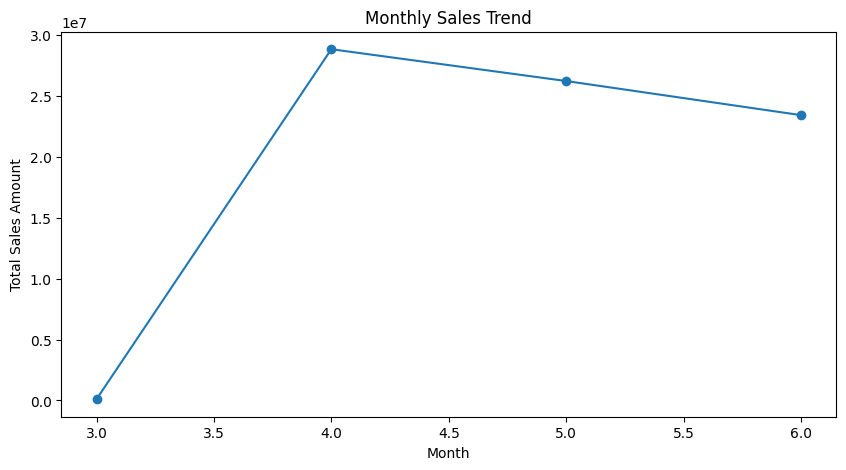

In [39]:
monthly_sales = df.groupby(df['Date'].dt.month)['Amount'].sum()

monthly_sales.plot(kind='line', marker='o', figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales Amount")
plt.show()

### The line chart shows the monthly sales trend over the observed period. Sales flunctuate across different months indicating changes in customer purchasing behaviour over time. Certain months recorded higher sales, which may be due to seasonal demand, promotional activities, or increased customer engagement. lower sales periods suggest possible off-peak seasons. This analysis helps identify periods of strong and weak business performance for better planning and decision-making.

 ### Grouped Comparison Analysis

In [27]:
df.groupby('Category')['Amount'].sum()

Category
Blouse             458408.18
Bottom             150667.98
Dupatta               915.00
Ethnic Dress       791217.66
Saree              123933.76
Set              39204124.03
Top               5347792.30
Western Dress    11216072.69
kurta            21299546.70
Name: Amount, dtype: float64

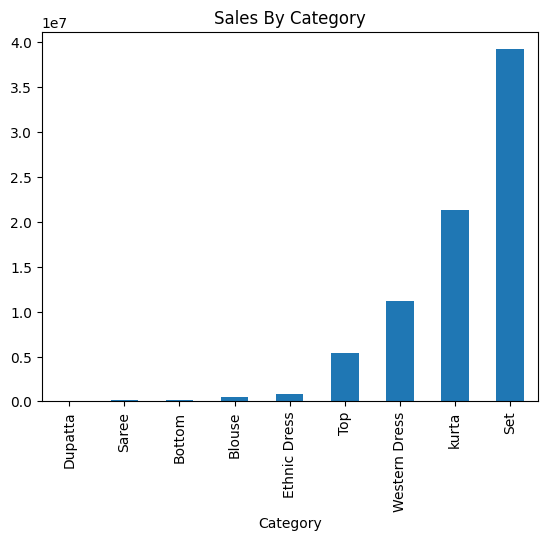

In [29]:
category_sales= df.groupby('Category')['Amount'].sum()

category_sales.sort_values().plot(kind='bar')
plt.title('Sales By Category')
plt.show()


### Relationship / Correlation Analysis

In [31]:
df[['Qty', 'Amount']].corr()

,Qty,Amount
Qty,1.0000,0.0669
Amount,0.0669,1.0000


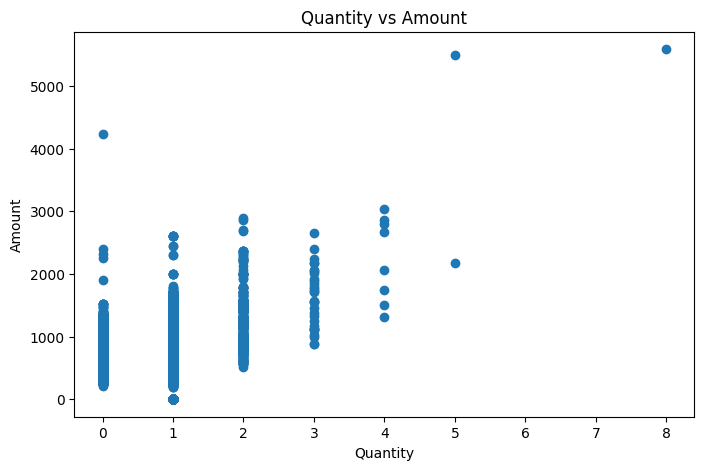

In [40]:
plt.figure(figsize=(8,5))
plt.scatter(df['Qty'], df['Amount'])
plt.xlabel('Quantity')
plt.ylabel('Amount')
plt.title('Quantity vs Amount')
plt.show()

### Top Selling Products

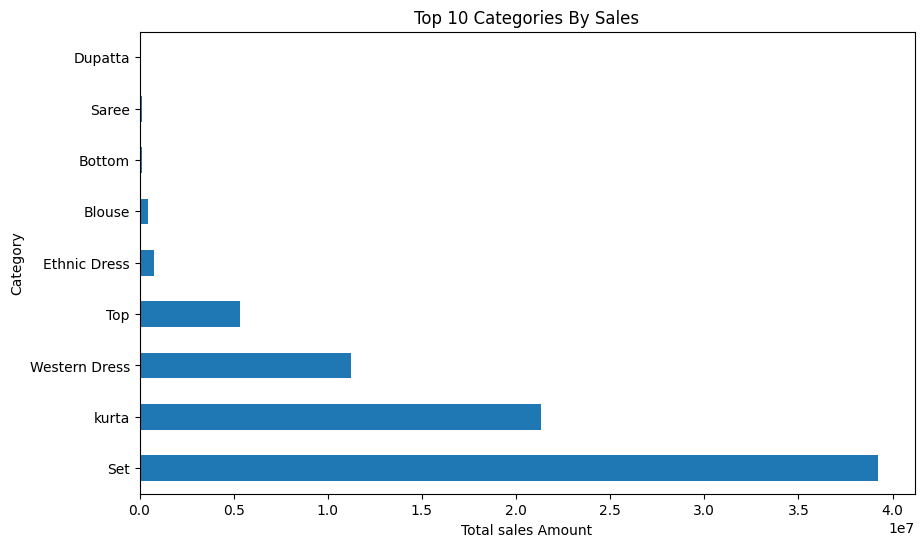

In [34]:
top_categories = df.groupby('Category')['Amount'].sum().sort_values(ascending=False).tail(10)

top_categories.plot(kind='barh', figsize=(10,6))

plt.title('Top 10 Categories By Sales')
plt.xlabel('Total sales Amount')
plt.ylabel('Category')
plt.show()

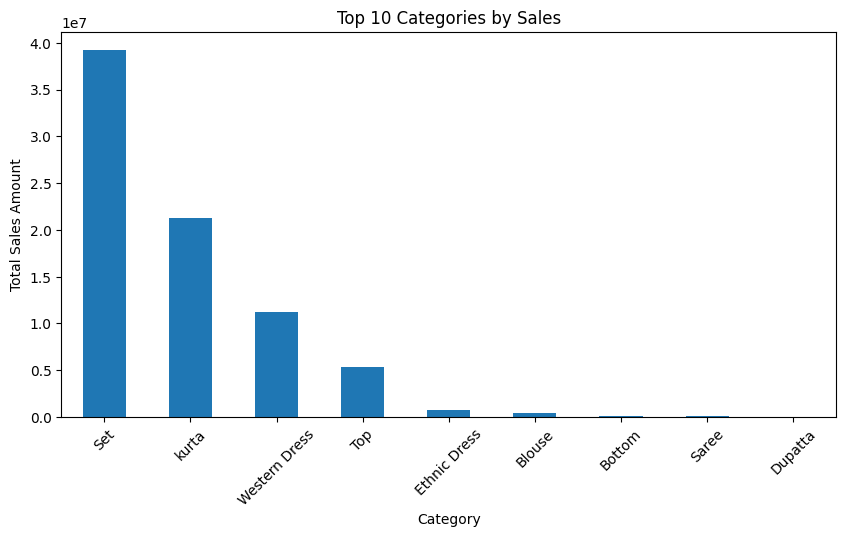

In [33]:
top_categories = df.groupby('Category')['Amount'].sum().sort_values(ascending=False).head(10)

top_categories.plot(kind='bar', figsize=(10,5))

plt.title('Top 10 Categories by Sales')
plt.xlabel('Category')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)

plt.show()
                    

#### The chart shows the top-performing product categories based on total sales amount. some categories generated significantly higher revenue compared to others, indicating stronger customer demand and better market performance. the leading categories contribute a large portion of overall sales, suggesting that the business should focus more marketing and inventory efforts on these products. lower-performing categories may require promotional strategies or product improvements to increase customer interest.

## Sales contribution Analysis

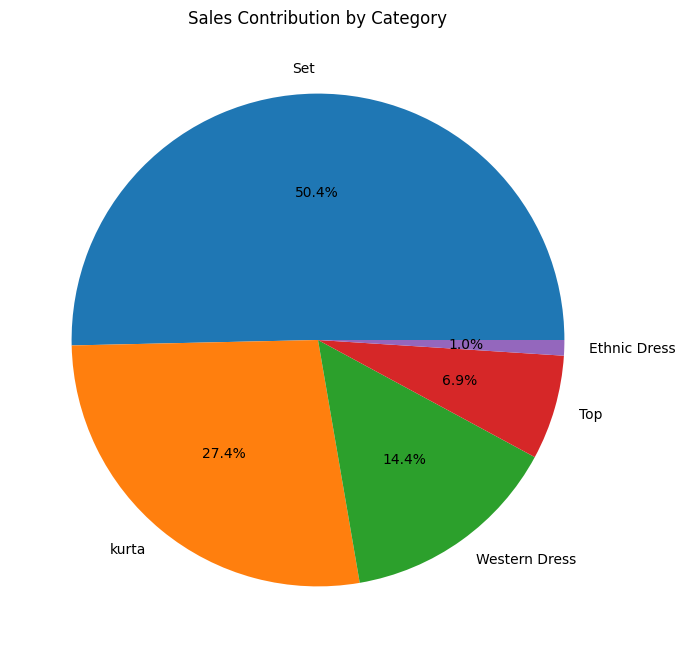

In [38]:
sales_contribution = df.groupby('Category')['Amount'].sum().sort_values(ascending=False).head(5)

sales_contribution.plot(kind='pie',
                        autopct='%1.1f%%',
                        figsize=(8,8))

plt.title("Sales Contribution by Category")
plt.ylabel("")
plt.show()
                                                        

#### the pie illustrates the percentage contribution of different product categories to total sales revenue. A few categories contribute a large share of overall sales, indicating that the customer demand is concentrated in specific product groups. The leading category dominates total revenue generation, while smaller categories contribute less significantly. this insight can help the business focus on high_performing categories to maximize profitability and improve strategic decision-making.